In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import os


df_list = []
for item in os.listdir("results/"):
    df = pd.read_csv("results/" + item)
    df_list.append(df.copy())
df = pd.concat(df_list, ignore_index=True)

df['x_parsed'] = df['x'].apply(lambda s: np.fromstring(s.strip('[]'), sep=' '))
df['x1'] = df['x_parsed'].apply(lambda arr: arr[0])
df['x2'] = df['x_parsed'].apply(lambda arr: arr[1])


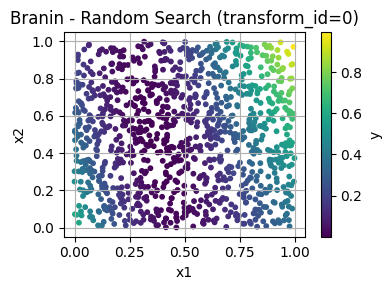

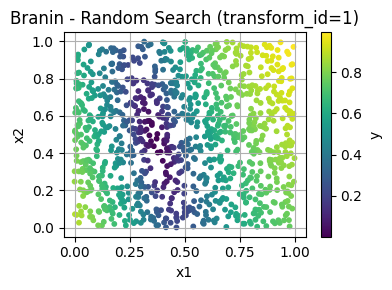

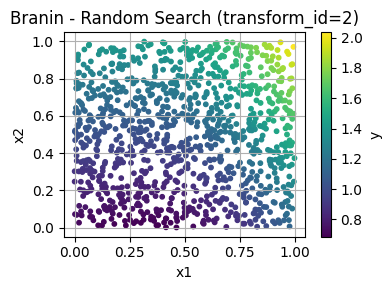

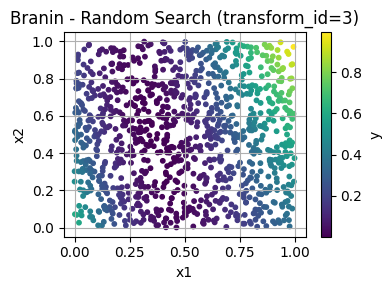

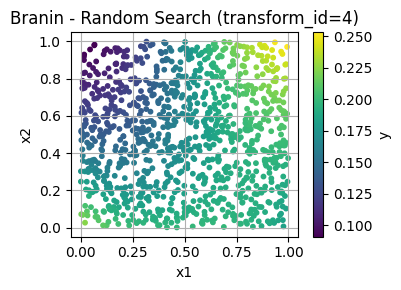

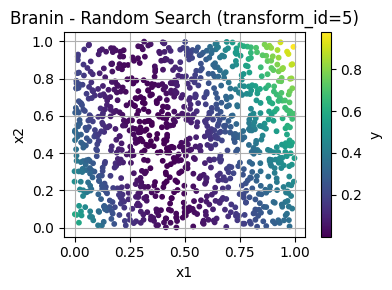

In [17]:
method = 'Random-Search'
dfm = df[df['method'] == method]
# Plot for each transform_id
unique_transforms = dfm['transform_id'].unique()

for transform_id in unique_transforms:
    df_subset = dfm[dfm['transform_id'] == transform_id]
    
    plt.figure(figsize=(4, 3))
    sc = plt.scatter(df_subset['x1'], df_subset['x2'], c=df_subset['y'], cmap='viridis', s=10)
    plt.colorbar(sc, label='y')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Branin - Random Search (transform_id={transform_id})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

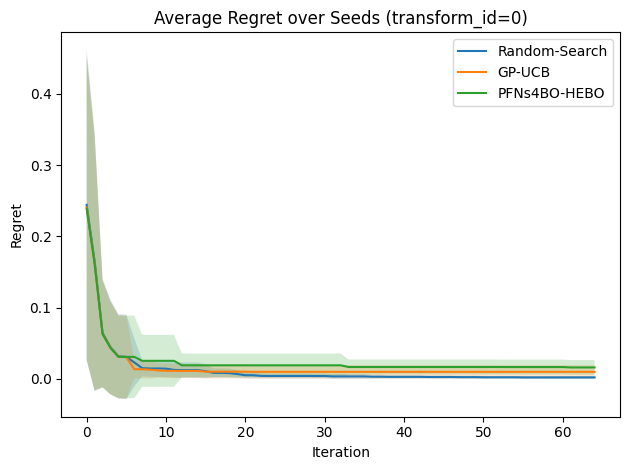

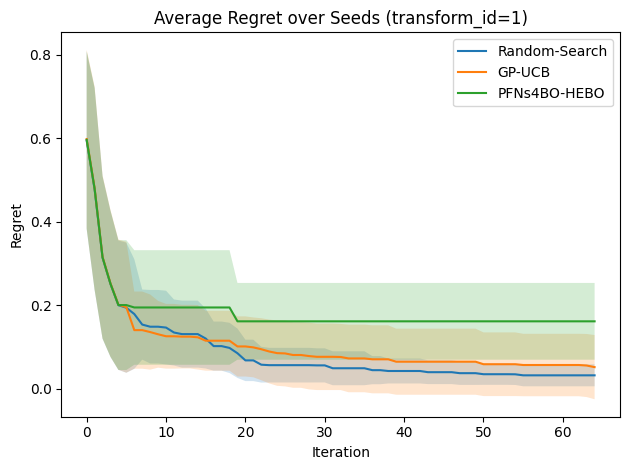

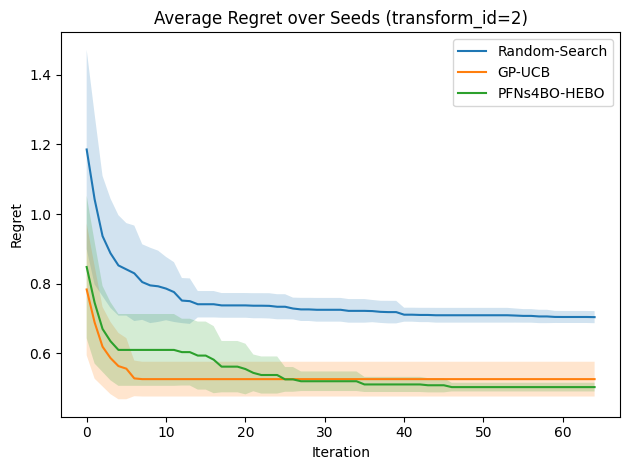

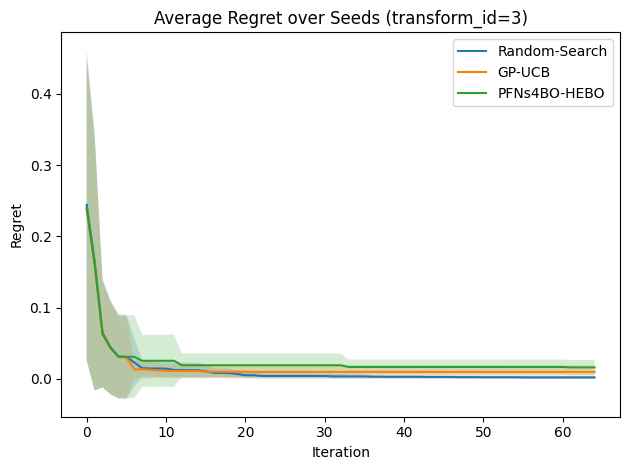

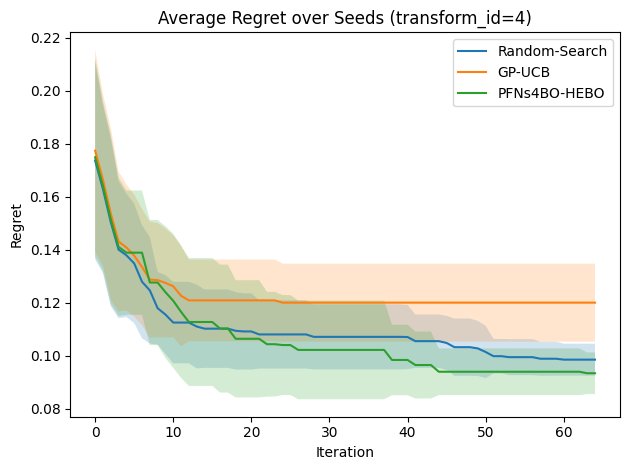

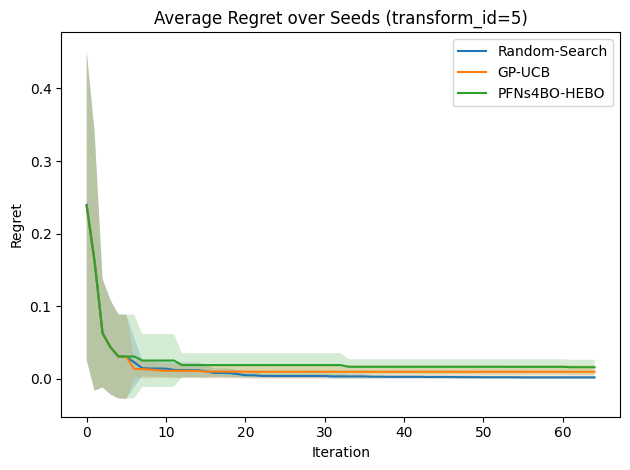

In [18]:

# Compute global optimum y* across all data

y_star = df['y'].min()
methods = df['method'].unique()

for transform_id in df['transform_id'].unique():
    for method in methods:
        df_sub = df[(df['transform_id'] == transform_id) & (df['method'] == method)]
        if df_sub.empty:
            continue
        pivot = df_sub.pivot(index='iteration', columns='seed', values='y').sort_index()
        
        incumbent = pivot.cummin()
        regret = incumbent - y_star
        
        mean_regret = regret.mean(axis=1)
        std_regret = regret.std(axis=1)
        
        # Plot with label for method
        plt.plot(mean_regret.index, mean_regret.values, label=method)
        plt.fill_between(mean_regret.index,
                         mean_regret - std_regret,
                         mean_regret + std_regret,
                         alpha=0.2)
    plt.xlabel("Iteration")
    plt.ylabel("Regret")
    plt.title(f"Average Regret over Seeds (transform_id={transform_id})")
    plt.tight_layout()
    plt.legend()
    plt.show()